# DBSCAN Clustering
### `Density-Based Spatial Clustering of Applications with Noise`

#### What is DBSCAN?

**DBSCAN** is a clustering algorithm that finds groups based on **density** — regions where data points are packed closely together.

Unlike K-Means, DBSCAN:
- Does **not** require you to specify the number of clusters beforehand
- Can find clusters of **any shape** (not just spherical)
- Automatically labels scattered, isolated points as **noise/outliers**

In a school context this is valuable because we may not know in advance how many pupil groups exist, and some pupils genuinely don't fit any group — they should be flagged, not forced into the nearest cluster.

---

## DBSCAN vs K-Means - Key Differences

| Feature | K-Means | DBSCAN |
|---------|---------|--------|
| Number of clusters | You must specify k | Found automatically |
| Cluster shape | Only round/spherical | Any shape |
| Outliers | Forced into a cluster | Labelled as noise (−1) |
| Parameters | `n_clusters` | `eps` and `min_samples` |
| Best for | Compact, well-separated blobs | Irregular shapes, noisy data |

---

## How DBSCAN Works — Three Types of Point

DBSCAN classifies every point using **two** parameters:

- **`eps`** — the search radius around each point (how far to look)
- **`min_samples`** — the minimum number of neighbours needed to form a dense region

```
CORE POINT   → has at least min_samples neighbours within eps distance
               These are the "heart" of a cluster.

BORDER POINT → has fewer than min_samples neighbours,
               but lies within eps of a core point.
               On the edge of a cluster.

NOISE POINT  → not a core point and not near any core point.
               Treated as an outlier. Labelled -1 by sklearn.
```

**The algorithm:**
1. Pick an unvisited point
2. Count its neighbours within `eps`
3. If ≥ `min_samples` → it is a core point; start a cluster and expand outward
4. Keep expanding until no more core points can be reached
5. Repeat for remaining unvisited points
6. Any point never reached = noise (label −1)

## Step 1 - Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Libraries imported.')

Libraries imported.


## Step 2 - Create the Dataset

We use a **UK secondary school pupil dataset**. Each row is one pupil described by two features:

- `attendance_pct` — percentage of sessions attended this term
- `sanctions` — total number of sanctions recorded this term

The data contains `three natural pupil groups`, plus some scattered outliers — pupils whose behaviour profile doesn't fit any group neatly.

This is a strong DBSCAN scenario because:
- We do not know in advance how many groups exist
- Outliers (e.g. a pupil with very high attendance but unusually high sanctions) should be flagged, not silently absorbed into the nearest cluster

| Group | Attendance | Sanctions | Profile |
|-------|-----------|-----------|--------|
| 1 | High (~93%) | Low (~1) | Engaged pupils |
| 2 | Mid (~80%) | Mid (~5) | Average / drifting pupils |
| 3 | Low (~65%) | High (~12) | Disengaged / at-risk pupils |

In [2]:
rng = np.random.default_rng(42)   # fixed seed — same data every run

# Group 1 — Engaged pupils: high attendance, very few sanctions
g1_att = rng.normal(93,  3,   80).clip(85, 100)  # attendance centred at 93%, std=3
g1_san = rng.normal(1,   0.8, 80).clip(0,  4)    # sanctions centred at 1, clipped to 0–4

# Group 2 — Average / drifting pupils: mid attendance, moderate sanctions
g2_att = rng.normal(80,  3,   70).clip(72, 88)   # attendance centred at 80%
g2_san = rng.normal(5,   1.5, 70).clip(2,  10)   # sanctions centred at 5

# Group 3 — Disengaged / at-risk pupils: low attendance, many sanctions
g3_att = rng.normal(65,  4,   50).clip(50, 75)   # attendance centred at 65%
g3_san = rng.normal(12,  2,   50).clip(7,  20)   # sanctions centred at 12

# Outliers — 20 pupils scattered randomly across the whole data space
# These represent genuinely unusual cases that don't belong to any group
out_att = rng.uniform(50, 100, 20)
out_san = rng.uniform(0,  20,  20)

# Stack all groups vertically into one array, then wrap in a DataFrame
data = np.vstack([
    np.column_stack([g1_att, g1_san]),
    np.column_stack([g2_att, g2_san]),
    np.column_stack([g3_att, g3_san]),
    np.column_stack([out_att, out_san]),
])
df = pd.DataFrame(data, columns=['attendance_pct', 'sanctions'])

print(f'Dataset: {df.shape[0]} pupils, {df.shape[1]} features')

Dataset: 220 pupils, 2 features


**Explaining the data generation above:**

- `rng.normal(mean, std, size)` — draws `size` random values from a normal (bell curve) distribution centred at `mean` with spread `std`. Most values fall within ±1 std of the mean.
- `.clip(min, max)` — prevents physically impossible values (e.g. attendance above 100% or negative sanctions). Any value outside the range is clamped to the nearest bound.
- `rng.uniform(low, high, size)` — draws values spread *evenly* between low and high, rather than clustering around a mean. Used for outliers so they scatter randomly across the whole data space.
- `np.column_stack([att, san])` — combines the two 1D arrays side by side into a 2-column block.
- `np.vstack([...])` — stacks all four blocks vertically into one array of shape (220, 2).

In [3]:
# Summary statistics — check the ranges look realistic
df.describe().round(2)

,attendance_pct,sanctions
count,220.00,220.00
mean,80.98,5.48
std,12.20,4.94
min,50.27,0.00
25%,71.80,1.18
50%,81.31,4.19
75%,92.04,9.59
max,99.42,19.60


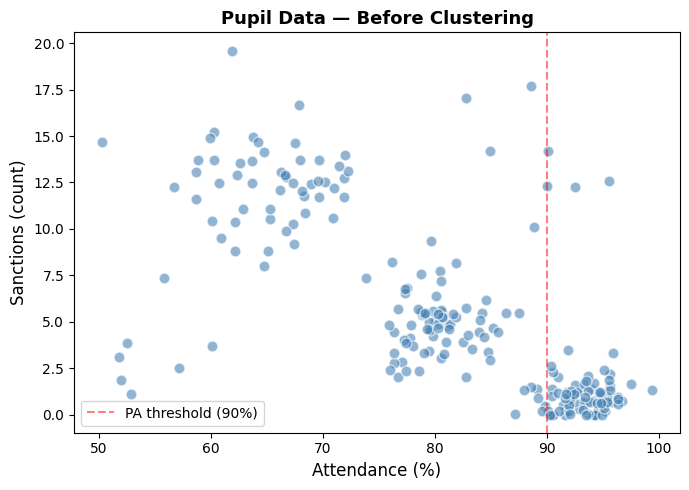

Can you already spot any natural groups?


In [4]:
# Plot the raw unlabelled data — this is what we see BEFORE clustering
plt.figure(figsize=(7, 5))
plt.scatter(df['attendance_pct'], df['sanctions'], color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.axvline(90, color='red', linestyle='--', alpha=0.5, label='PA threshold (90%)')
plt.xlabel('Attendance (%)', fontsize=12)
plt.ylabel('Sanctions (count)', fontsize=12)
plt.title('Pupil Data — Before Clustering', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print('Can you already spot any natural groups?')

## Step 3 - Scale the Data

DBSCAN, like K-Means, uses **distance** to find neighbours. `attendance_pct` ranges from 50–100 and `sanctions` from 0–20 — different scales that would skew distance calculations if left as-is.

`StandardScaler` puts both features on the same scale: **mean = 0, std = 1**.

Always scale before running any distance-based algorithm.

In [5]:
# Fit the scaler and transform both features to the same scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)   # returns a numpy array (220, 2)

print('After scaling (both features now on the same scale):')
print(f'  Mean : {X_scaled.mean(axis=0).round(3)}')  # should be ~[0, 0]
print(f'  Std  : {X_scaled.std(axis=0).round(3)}')   # should be ~[1, 1]

After scaling (both features now on the same scale):
  Mean : [-0. -0.]
  Std  : [1. 1.]


## Step 4 - Choose eps Using the k-Distance Plot

The two parameters we must set are:

**`min_samples`** — a good rule of thumb: use **2 × number of features**. With 2 features, `min_samples = 5` is a sensible default. This means a point needs 4 neighbours within `eps` to be considered a core point.

**`eps`** — harder to choose by intuition. The **k-distance plot** helps:

1. For each point, compute its distance to its `k`-th nearest neighbour (where `k = min_samples`)
2. Sort these distances smallest to largest and plot them
3. Look for the **elbow** — the sharp bend in the curve
4. The distance at the elbow is your `eps`

**Why the elbow?** Points to the left are in dense regions (short distances to neighbours = inside a cluster). Points to the right are in sparse regions (far from neighbours = outliers). The elbow marks the transition between dense and sparse — exactly the boundary DBSCAN should use.

In [6]:
k = 5   # same value we will use for min_samples

# Fit a nearest-neighbour model to find distances to the k-th neighbour
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)

# kneighbors returns two arrays: distances and indices
# distances shape: (n_pupils, k) — distance to each of the k neighbours
distances, _ = nn.kneighbors(X_scaled)

# Take column index k-1 (the k-th neighbour) and sort ascending
kth_distances = np.sort(distances[:, k - 1])

In [7]:
# Preview the first 10 k-th distances — these are tight cluster members
kth_distances[:10].round(3)

array([0.038, 0.039, 0.042, 0.043, 0.043, 0.045, 0.045, 0.045, 0.048,
       0.048])

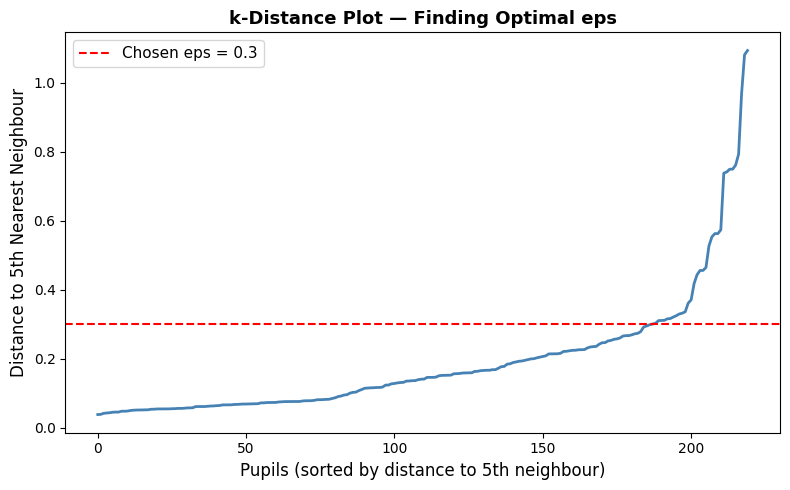

Look for the sharp bend (elbow) in the curve.
The distance at the elbow is a good choice for eps.


In [8]:
# Plot the k-distance graph — look for the sharp elbow
plt.figure(figsize=(8, 5))
plt.plot(kth_distances, color='steelblue', linewidth=2)

# Mark the chosen eps with a horizontal dashed line
# The elbow in this dataset appears around distance 0.3
plt.axhline(y=0.3, color='red', linestyle='--', linewidth=1.5, label='Chosen eps = 0.3')

plt.xlabel('Pupils (sorted by distance to 5th neighbour)', fontsize=12)
plt.ylabel(f'Distance to {k}th Nearest Neighbour', fontsize=12)
plt.title('k-Distance Plot — Finding Optimal eps', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Look for the sharp bend (elbow) in the curve.')
print('The distance at the elbow is a good choice for eps.')

## Step 5 - Fit DBSCAN

Now we fit the model using the `eps` and `min_samples` values chosen from the k-distance plot.

`fit_predict()` fits the model and returns a **label for every pupil**:
- `0, 1, 2, …` — cluster numbers
- `-1` — noise/outlier (not assigned to any cluster)

In [9]:
# Fit DBSCAN with the parameters chosen from the k-distance plot
# eps=0.3     → search radius in scaled units — pupils within this distance are neighbours
# min_samples=5 → a pupil needs 4 neighbours within eps to be a core point
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)   # returns array of labels, one per pupil


In [10]:
# Count how many clusters were found (excluding -1 which is noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()   # count pupils labelled as outliers

print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise}')
print(f'\nLabel counts:')
for label in sorted(set(labels)):
    name = 'Noise' if label == -1 else f'Cluster {label}'  # human-readable label
    print(f'  {name:<12}: {(labels == label).sum()} pupils')

Clusters found : 3
Noise points   : 20

Label counts:
  Noise       : 20 pupils
  Cluster 0   : 82 pupils
  Cluster 1   : 69 pupils
  Cluster 2   : 49 pupils


## Step 6 - Visualise the DBSCAN Results

We plot each cluster in a different colour. **Noise points** (label = −1) are shown as small grey crosses so they stand out clearly from the assigned clusters.

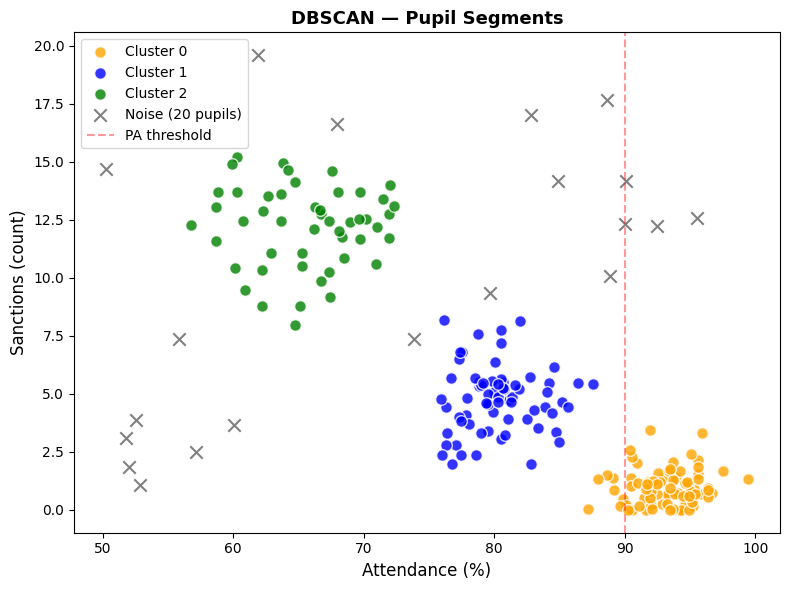

In [11]:
# Add cluster labels back to the original (unscaled) DataFrame for plotting
df['cluster'] = labels

# One colour per cluster; noise points will be plotted separately in grey
cluster_colours = {0: 'orange', 1: 'blue', 2: 'green'}

plt.figure(figsize=(8, 6))

# Plot each cluster in its own colour
for cluster_id, colour in cluster_colours.items():
    mask = df['cluster'] == cluster_id   # select only pupils in this cluster
    if mask.sum() > 0:                   # guard against empty clusters
        plt.scatter(df.loc[mask, 'attendance_pct'],
                    df.loc[mask, 'sanctions'],
                    c=colour, label=f'Cluster {cluster_id}',
                    s=70, alpha=0.8, edgecolors='white')

# Plot noise points separately — grey X markers so they stand out
noise_mask = df['cluster'] == -1         # -1 is DBSCAN's label for outliers
plt.scatter(df.loc[noise_mask, 'attendance_pct'],
            df.loc[noise_mask, 'sanctions'],
            c='grey', marker='x', s=80, linewidths=1.5,
            label=f'Noise ({noise_mask.sum()} pupils)')  # count embedded in label

plt.axvline(90, color='red', linestyle='--', alpha=0.4, label='PA threshold')
plt.xlabel('Attendance (%)', fontsize=12)
plt.ylabel('Sanctions (count)', fontsize=12)
plt.title('DBSCAN — Pupil Segments', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Explaining the key lines above:**

- `df['cluster'] = labels` — stores the DBSCAN output (an array like `[0, 1, -1, 2, ...]`) as a new column so each pupil row carries its cluster assignment.
- `mask = df['cluster'] == cluster_id` — creates a True/False series the same length as the DataFrame; True only for pupils in the current cluster. Used to slice out just those rows for plotting.
- `if mask.sum() > 0` — `mask.sum()` counts the True values (number of pupils in this cluster). The guard prevents trying to plot an empty cluster.
- `noise_mask = df['cluster'] == -1` — selects exactly the outlier rows since DBSCAN always uses −1 for noise.
- `noise_mask.sum()` — automatically counts and displays the number of noise pupils in the legend.

## Step 7 - DBSCAN vs K-Means Side by Side

One of the most important strengths of DBSCAN is how it handles **outliers**. K-Means forces every pupil into a cluster — even unusual, isolated cases. DBSCAN labels them as noise instead, which is far more useful for pastoral staff who need to know which pupils genuinely don't fit any group.

The plot below runs both algorithms on the same data so you can compare directly.

In [12]:
# Run K-Means with k=3 on the same scaled data for comparison
# We tell K-Means the number of clusters (3) — DBSCAN found this automatically
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

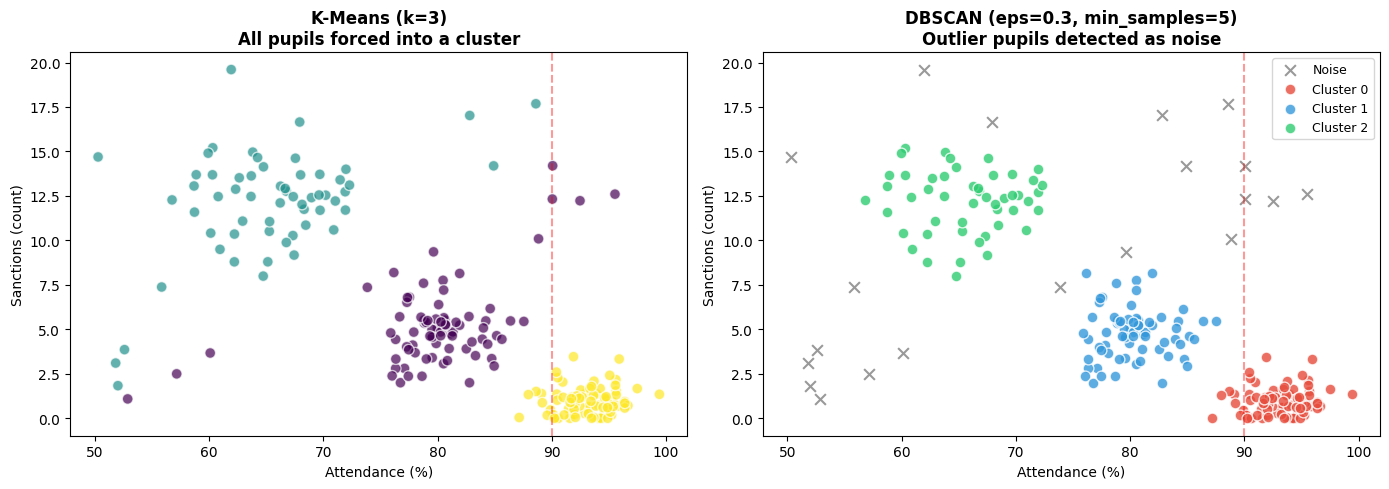

K-Means : every outlier pupil is silently absorbed into the nearest cluster.
DBSCAN  : outlier pupils are correctly identified and flagged — ready for review.


In [13]:
# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: K-Means ──────────────────────────────────────────────────────
# All 220 pupils coloured by K-Means cluster — outliers are silently absorbed
axes[0].scatter(df['attendance_pct'], df['sanctions'],
                c=kmeans_labels, cmap='viridis',
                s=60, alpha=0.7, edgecolors='white')
axes[0].axvline(90, color='red', linestyle='--', alpha=0.4)
axes[0].set_title('K-Means (k=3)\nAll pupils forced into a cluster',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('Sanctions (count)')

# ── Right: DBSCAN ──────────────────────────────────────────────────────
# Cluster pupils in colour, noise pupils as grey X markers
colours_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', -1: 'grey'}

for l in sorted(set(labels)):                  # loop over cluster ids including -1
    mask = df['cluster'] == l
    name = 'Noise' if l == -1 else f'Cluster {l}'
    m    = 'x'     if l == -1 else 'o'          # X marker for noise, circle for clusters
    axes[1].scatter(df.loc[mask, 'attendance_pct'],
                    df.loc[mask, 'sanctions'],
                    c=colours_map.get(l, 'black'), marker=m,
                    s=60, alpha=0.8, edgecolors='white', label=name)

axes[1].axvline(90, color='red', linestyle='--', alpha=0.4)
axes[1].set_title('DBSCAN (eps=0.3, min_samples=5)\nOutlier pupils detected as noise',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Sanctions (count)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('K-Means : every outlier pupil is silently absorbed into the nearest cluster.')
print('DBSCAN  : outlier pupils are correctly identified and flagged — ready for review.')

## Step 8 - Interpret the Results

Numbers alone don't tell the full story. We compute the mean attendance and sanctions for each cluster and assign a meaningful pastoral label so staff can act on the output.

In [14]:
# Summarise each cluster using original (unscaled) feature values
# Exclude noise points (-1) from the summary — they have no cluster
cluster_summary = (
    df[df['cluster'] != -1]   # filter out noise rows
    .groupby('cluster')[['attendance_pct', 'sanctions']]
    .mean()
    .round(1)
)
# Add pupil count per cluster
cluster_summary['count'] = (
    df[df['cluster'] != -1].groupby('cluster')['cluster'].count()
)

print('Cluster Profiles (noise excluded):')
print(cluster_summary)
print(f'\nNoise pupils : {(df["cluster"] == -1).sum()}  (flagged as outliers — no cluster assigned)')

Cluster Profiles (noise excluded):
         attendance_pct  sanctions  count
cluster                                  
0                  93.1        0.9     82
1                  80.3        4.8     69
2                  65.6       12.2     49

Noise pupils : 20  (flagged as outliers — no cluster assigned)


In [15]:
# Assign a meaningful pastoral label to each cluster
# Labels are derived from the mean attendance and sanctions values in the summary
pupil_labels = {}
for seg, row in cluster_summary.iterrows():
    if row['attendance_pct'] > 88:    # high attendance group
        pupil_labels[seg] = 'Engaged Pupils'
    elif row['sanctions'] > 9:        # low attendance, many sanctions
        pupil_labels[seg] = 'Disengaged / At-Risk Pupils'
    else:                             # middle group
        pupil_labels[seg] = 'Average / Drifting Pupils'

# .map() looks up each cluster index in the dictionary and returns its label
cluster_summary['pastoral_label'] = cluster_summary.index.map(pupil_labels)
print(cluster_summary[['pastoral_label', 'attendance_pct', 'sanctions', 'count']].to_string())

                      pastoral_label  attendance_pct  sanctions  count
cluster                                                               
0                     Engaged Pupils            93.1        0.9     82
1          Average / Drifting Pupils            80.3        4.8     69
2        Disengaged / At-Risk Pupils            65.6       12.2     49


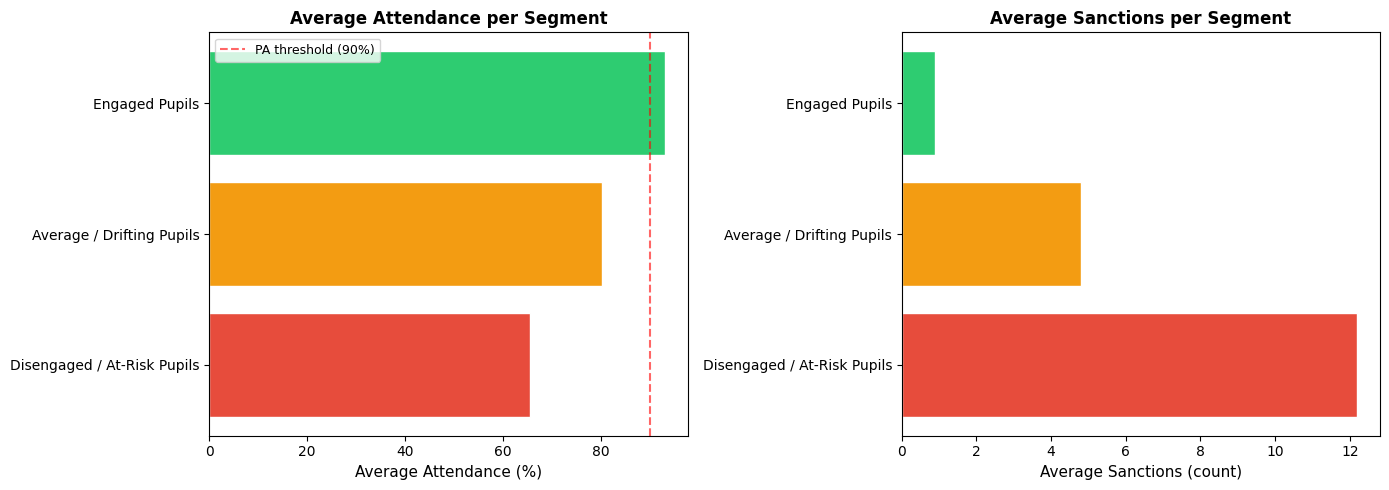

In [16]:
# Bar charts: average attendance and average sanctions per labelled segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order segments by attendance for a logical reading order
seg_order  = cluster_summary.sort_values('attendance_pct').index
bar_labels = [pupil_labels[s] for s in seg_order]
colours    = ['#e74c3c', '#f39c12', '#2ecc71']   # red=at-risk, amber=average, green=engaged

# Attendance chart — red dashed line shows PA threshold
axes[0].barh(bar_labels, cluster_summary.loc[seg_order, 'attendance_pct'],
             color=colours, edgecolor='white')
axes[0].axvline(90, color='red', linestyle='--', alpha=0.6, label='PA threshold (90%)')
axes[0].set_xlabel('Average Attendance (%)', fontsize=11)
axes[0].set_title('Average Attendance per Segment', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Sanctions chart
axes[1].barh(bar_labels, cluster_summary.loc[seg_order, 'sanctions'],
             color=colours, edgecolor='white')
axes[1].set_xlabel('Average Sanctions (count)', fontsize=11)
axes[1].set_title('Average Sanctions per Segment', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Summary - DBSCAN Workflow

```
1. Load and understand the data
2. Scale features with StandardScaler — essential for distance-based algorithms
3. Choose min_samples = 2 × number of features (5 for 2D data)
4. Use the k-distance plot to find a good eps (look for the elbow)
5. Fit:     dbscan = DBSCAN(eps=..., min_samples=...)
            labels = dbscan.fit_predict(X_scaled)
6. Inspect: labels == -1  → noise/outlier pupils
7. Interpret each cluster using mean feature values
8. Tune eps if the number of clusters or noise count looks wrong
```

### Pastoral interpretation of results

| Cluster | Attendance | Sanctions | Label | Suggested action |
|---------|-----------|-----------|-------|------------------|
| Engaged Pupils | High | Very low | ✅ | Monitor and maintain |
| Average / Drifting | Mid | Moderate | ⚠️ | Watch for deterioration; light-touch support |
| Disengaged / At-Risk | Low | High | 🔴 | Priority pastoral plan; family contact |
| Noise (−1) | Varies | Varies | 🔍 | Individual review — unusual profile, no group fit |

### When to choose DBSCAN over K-Means

| Situation | Better choice |
|-----------|---------------|
| You don't know how many groups exist | **DBSCAN** |
| Clusters are irregular or curved shapes | **DBSCAN** |
| You need outlier pupils to be flagged | **DBSCAN** |
| Clusters are round and roughly equal size | **K-Means** |
| Dataset is very large (speed matters) | **K-Means** |